# Equation-to-Code Walkthrough

This notebook follows one thread from the full SILVA equation to executable
package objects:

$$
z^\star
=
\Psi_\theta\!\left(
S_\theta(x)
+H_\theta(a(z^\star))
+L_\theta(a(z^\star),E)
+G_\theta(a(z^\star),b)
\right).
$$

By setting terms to zero or choosing different operators, the same package API
recovers compact DEQ layers, message-passing DEQs, and full SILVA graph layers.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[10]](https://jseluis.github.io/silva-networks/paper/references/#ref-10), [[11]](https://jseluis.github.io/silva-networks/paper/references/#ref-11), [[13]](https://jseluis.github.io/silva-networks/paper/references/#ref-13). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import (
    SILVAGraphNetwork,
    SolverConfig,
    full_jacobian,
    make_knn_edge_index,
    resolve_device,
    silva_deq_reduction_layer,
    silva_message_passing_reduction_layer,
    stability_report,
)

torch.manual_seed(8)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Step 1: Compact DEQ as a SILVA Reduction

Start from the full equation and set

$$
L_\theta=0,\qquad G_\theta=0,\qquad a(z)=z,\qquad
H_\theta(z)=W_z z.
$$

With $S_\theta(x)=W_xx+b$ and $\Psi=\tanh$, substitution gives

$$
z^\star
=
\tanh(W_xx+b+W_z z^\star).
$$

In [3]:
x = torch.randn(12, 4, device=device)
deq_layer = silva_deq_reduction_layer(
    in_dim=4,
    hidden_dim=6,
    config=SolverConfig(solver="anderson", max_iter=12, alpha=0.6, history=4),
).to(device)

z = torch.randn(12, 6, device=device)
manual = torch.tanh(deq_layer.stimulus(x) + deq_layer.self_term(z))
from_layer = deq_layer.f(z, x)
float((manual - from_layer).abs().max().detach().cpu())

0.0

In [4]:
deq_result = deq_layer(x, return_result=True)
deq_result.z.shape, deq_result.iterations, deq_result.residual

(torch.Size([12, 6]), 12, 0.0026819880586117506)

## Step 2: Message Passing as a Local SILVA Field

Keep a local operator and remove the learned self and global branches:

$$
z^\star=\Psi_\theta(S_\theta(x)+L_\theta(a(z^\star),E)).
$$

For a graph, $E$ is encoded by `edge_index`. The first row stores sources and
the second row stores destinations.

In [5]:
edge_index = make_knn_edge_index(x, k=3, undirected=True, device=device)
mp_layer = silva_message_passing_reduction_layer(
    in_dim=4,
    hidden_dim=6,
    local="gat",
    local_kwargs={"heads": 2},
    config=SolverConfig(solver="picard", max_iter=8, alpha=0.5),
).to(device)

mp_result = mp_layer(x, edge_index=edge_index, return_result=True)
mp_result.z.shape, edge_index.shape, mp_result.residual

(torch.Size([12, 6]), torch.Size([2, 50]), 1.6806175708770752)

## Step 3: Turn the Full SILVA Field Back On

A stack can use different branch choices and solver settings per layer:

$$
z_{\ell}^{\star}
=
\Psi_{\theta_\ell}
\left(
S_{\theta_\ell}(x_\ell)
+H_{\theta_\ell}
+L_{\theta_\ell}
+G_{\theta_\ell}
\right).
$$

In [6]:
model = SILVAGraphNetwork(
    in_dim=4,
    hidden_dims=[10, 8],
    out_dim=3,
    task="node",
    local=["graph", "gat"],
    global_term=["mean", "topk"],
    self_term=["none", "linear"],
    local_kwargs=[None, {"heads": 2}],
    global_kwargs=[None, {"k": 4}],
    config=[
        SolverConfig(solver="picard", max_iter=6, alpha=0.5),
        SolverConfig(solver="anderson", max_iter=8, alpha=0.35, history=4),
    ],
).to(device)

out = model(x, edge_index=edge_index, return_results=True)
out.output.shape, out.state.shape, [r.solver for r in out.solver_results]

(torch.Size([12, 3]), torch.Size([12, 8]), ['picard', 'anderson'])

## Step 4: Diagnose the Equilibrium

The residual is

$$
\|f_\theta(z^\star,x)-z^\star\|_2.
$$

For small states, the full Jacobian can be materialized. For larger states,
matrix-free `vjp` and `jvp` calls are preferred.

In [7]:
small_x = x[:2]
small_layer = silva_deq_reduction_layer(
    in_dim=4,
    hidden_dim=3,
    config=SolverConfig(solver="picard", max_iter=10, alpha=0.5),
).to(device)
small_result = small_layer(small_x, return_result=True)

J = full_jacobian(lambda state: small_layer.f(state, small_x), small_result.z)
report = stability_report(
    lambda state: small_layer.f(state, small_x),
    small_result.z,
    samples=2,
    iters=4,
)
J.shape, report

(torch.Size([6, 6]),
 StabilityReport(residual=0.004042531829327345, spectral_radius=0.3276681900024414, jacobian_norm_estimate=0.6150436997413635, samples=2))

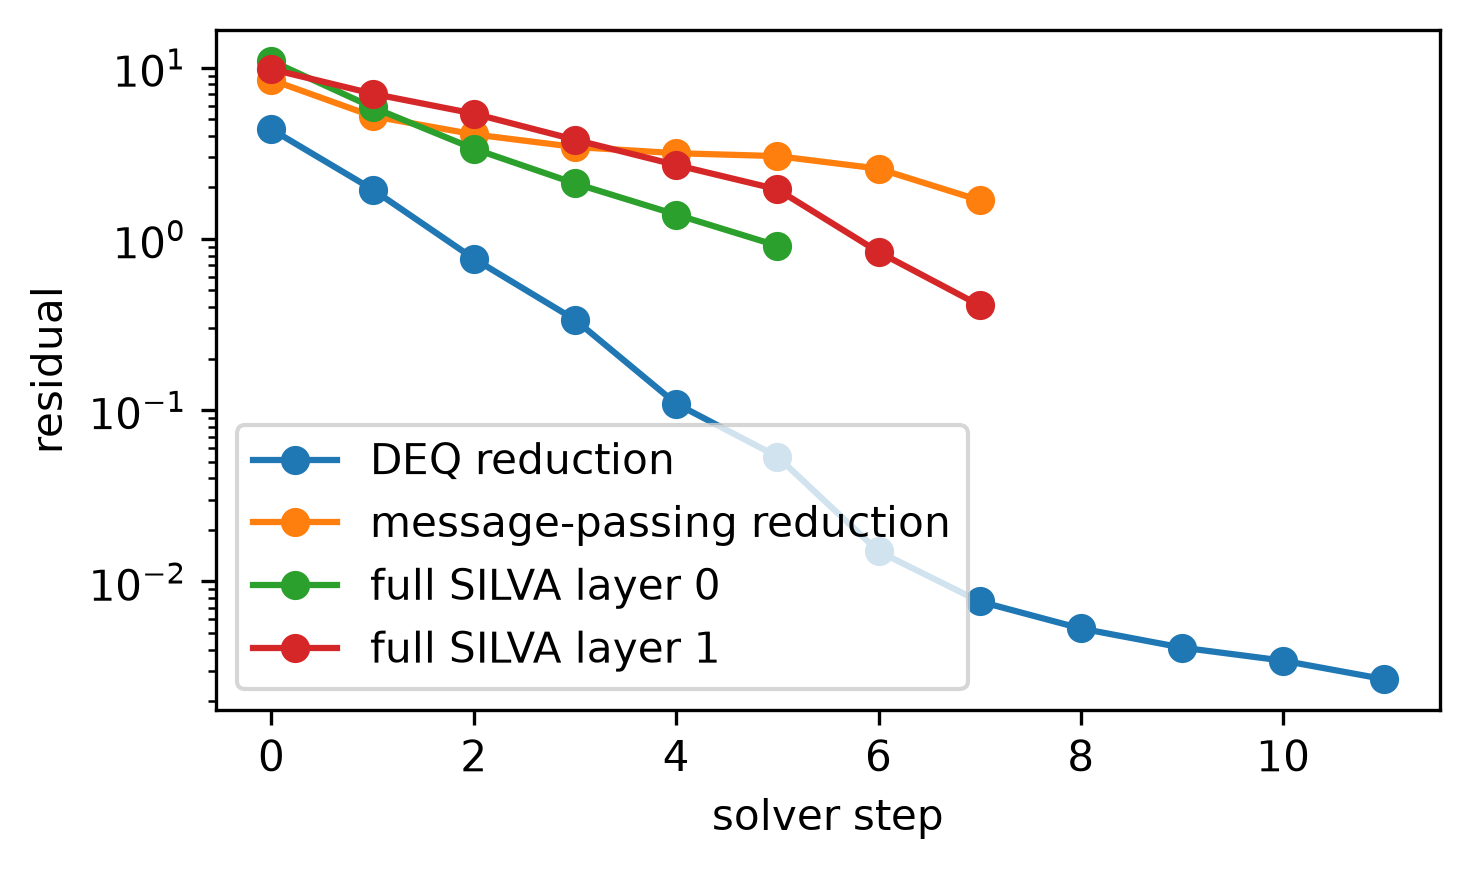

In [8]:
plt.figure(figsize=(5, 3))
plt.plot(deq_result.residuals, marker="o", label="DEQ reduction")
plt.plot(mp_result.residuals, marker="o", label="message-passing reduction")
for index, solver_result in enumerate(out.solver_results):
    plt.plot(solver_result.residuals, marker="o", label=f"full SILVA layer {index}")
plt.yscale("log")
plt.xlabel("solver step")
plt.ylabel("residual")
plt.legend()
plt.tight_layout()

## Citation

If this notebook or package is used, cite:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.2.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work is connected to the SILVA Networks methodology, cite the SILVA
Networks paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Related sources:

- Deep Equilibrium Models: https://arxiv.org/abs/1909.01377
- Graph Attention Networks: https://arxiv.org/abs/1710.10903
- TorchDEQ: https://github.com/locuslab/torchdeq

## From 08 Equation To Code Walkthrough to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the evolving or terminal physical state |
| Condition | time, initial condition, and external forcing |
| Repeated computation | an explicit flow step or residual field T(z, x) - z |
| Required invariants | time-step shape, initial condition, and integration consistency |
| Replaceable components | vector field, integrator, equilibrium transition, readout, and tolerances |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [9]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**trajectory error, terminal fixed-point residual, and conservation error**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **time horizon, step count, state dimension, and stiffness**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [10]:
notebook_reproduction_record = {
    "notebook": '08_equation_to_code_walkthrough.ipynb',
    "state": 'the evolving or terminal physical state',
    "condition": 'time, initial condition, and external forcing',
    "transition": 'an explicit flow step or residual field T(z, x) - z',
    "invariants": 'time-step shape, initial condition, and integration consistency',
    "compact_metric": 'trajectory error, terminal fixed-point residual, and conservation error',
    "scale_axis": 'time horizon, step count, state dimension, and stiffness',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '08_equation_to_code_walkthrough.ipynb',
 'state': 'the evolving or terminal physical state',
 'condition': 'time, initial condition, and external forcing',
 'transition': 'an explicit flow step or residual field T(z, x) - z',
 'invariants': 'time-step shape, initial condition, and integration consistency',
 'compact_metric': 'trajectory error, terminal fixed-point residual, and conservation error',
 'scale_axis': 'time horizon, step count, state dimension, and stiffness'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **implicit dynamics factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the evolving or terminal physical state**, and its repeated map,
**an explicit flow step or residual field T(z, x) - z**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [11]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('implicit dynamics factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


implicit dynamics factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


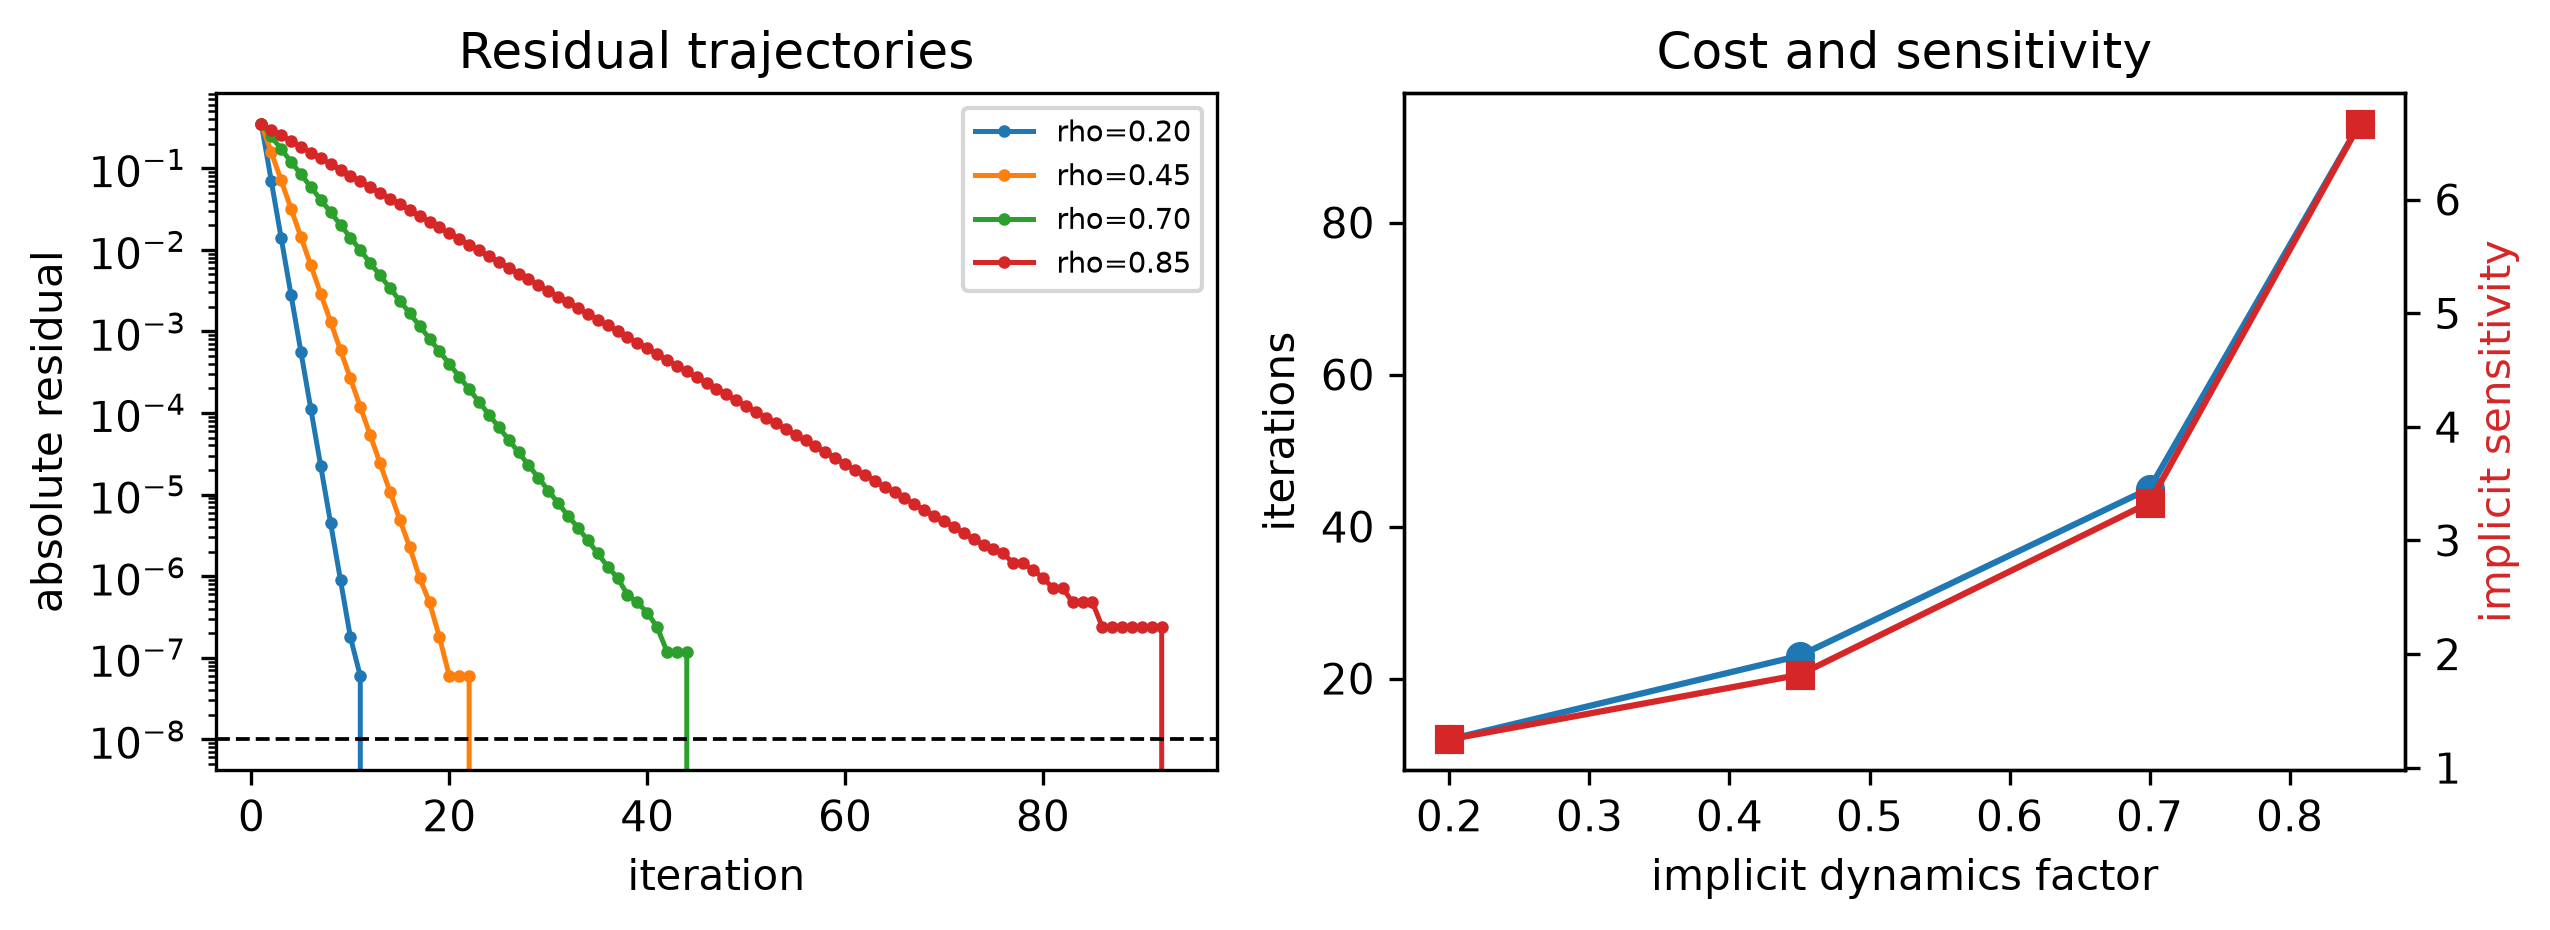

In [12]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('implicit dynamics factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the implicit dynamics factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | trajectory error, terminal fixed-point residual, and conservation error |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | time-step shape, initial condition, and integration consistency |
| Scale sweep | Change one of time horizon, step count, state dimension, and stiffness at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| Where is the complete derivation sequence explained? | [Derivation Workbook](https://jseluis.github.io/silva-networks/learn/derivation-workbook/) |
| How is a full SILVA layer assembled? | [SILVA From Scratch](https://jseluis.github.io/silva-networks/learn/silva-from-scratch/) |
| Which layer contracts implement the derived branches? | [Layers API](https://jseluis.github.io/silva-networks/api/layers/) |
